In [50]:
!pip -q install pyarrow xgboost shap

In [51]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob
import pandas as pd
import numpy as np

DATA_DIR = "/content/drive/MyDrive/NYC_TLC"
print("DATA_DIR:", DATA_DIR)

print("\nFiles in DATA_DIR:")
for f in sorted(os.listdir(DATA_DIR)):
    print(" -", f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR: /content/drive/MyDrive/NYC_TLC

Files in DATA_DIR:
 - outputs
 - taxi_zone_lookup.csv
 - yellow_tripdata_2025-10.parquet
 - yellow_tripdata_2025-11.parquet
 - yellow_tripdata_2025-12.parquet
 - yellow_tripdata_2026-01.parquet
 - yellow_tripdata_2026-02.parquet


In [52]:
import pandas as pd

zones_fp = f"{DATA_DIR}/taxi_zone_lookup.csv"
zones = pd.read_csv(zones_fp)

print("Zone lookup shape:", zones.shape)
print("Zone lookup columns:", list(zones.columns))
zones.head()

Zone lookup shape: (265, 4)
Zone lookup columns: ['LocationID', 'Borough', 'Zone', 'service_zone']


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [53]:
import os
import pandas as pd

#Fixing required column names for Yellow taxi
PICKUP_COL = "tpep_pickup_datetime"
PU_COL = "PULocationID"

trip_files = [
    f"{DATA_DIR}/yellow_tripdata_2025-10.parquet",
    f"{DATA_DIR}/yellow_tripdata_2025-11.parquet",
    f"{DATA_DIR}/yellow_tripdata_2025-12.parquet",
    f"{DATA_DIR}/yellow_tripdata_2026-01.parquet",
    f"{DATA_DIR}/yellow_tripdata_2026-02.parquet"
]

print("Trip files being used:")
for f in trip_files:
    print(" -", os.path.basename(f))

keep_cols = [PICKUP_COL, PU_COL]

dfs = []
for fp in trip_files:
    temp = pd.read_parquet(fp, columns=keep_cols)
    temp["source_file"] = os.path.basename(fp)  # Tracking month source
    dfs.append(temp)

trips = pd.concat(dfs, ignore_index=True)

print("Combined trips shape:", trips.shape)
trips.head()

Trip files being used:
 - yellow_tripdata_2025-10.parquet
 - yellow_tripdata_2025-11.parquet
 - yellow_tripdata_2025-12.parquet
 - yellow_tripdata_2026-01.parquet
 - yellow_tripdata_2026-02.parquet
Combined trips shape: (20039904, 3)


,tpep_pickup_datetime,PULocationID,source_file
0,2025-10-01 00:15:32,132,yellow_tripdata_2025-10.parquet
1,2025-10-01 00:00:08,107,yellow_tripdata_2025-10.parquet
2,2025-10-01 00:08:54,263,yellow_tripdata_2025-10.parquet
3,2025-10-01 00:58:48,211,yellow_tripdata_2025-10.parquet
4,2025-10-01 00:39:51,230,yellow_tripdata_2025-10.parquet


In [54]:
# Converting pickup time to datetime
trips[PICKUP_COL] = pd.to_datetime(trips[PICKUP_COL], errors="coerce")

# Removing rows with missing pickup time
before = len(trips)
trips = trips.dropna(subset=[PICKUP_COL, PU_COL])
after = len(trips)

print("Rows before cleaning:", before)
print("Rows after cleaning :", after)
print("Dropped rows        :", before - after)

# Ensuring pickup location IDs are integers
trips[PU_COL] = trips[PU_COL].astype(int)

#Creating an hourly time column
trips["hour"] = trips[PICKUP_COL].dt.floor("h")

print("Hour range:", trips["hour"].min(), "to", trips["hour"].max())
trips.head()

Rows before cleaning: 20039904
Rows after cleaning : 20039904
Dropped rows        : 0
Hour range: 2008-12-31 23:00:00 to 2026-03-01 00:00:00


,tpep_pickup_datetime,PULocationID,source_file,hour
0,2025-10-01 00:15:32,132,yellow_tripdata_2025-10.parquet,2025-10-01
1,2025-10-01 00:00:08,107,yellow_tripdata_2025-10.parquet,2025-10-01
2,2025-10-01 00:08:54,263,yellow_tripdata_2025-10.parquet,2025-10-01
3,2025-10-01 00:58:48,211,yellow_tripdata_2025-10.parquet,2025-10-01
4,2025-10-01 00:39:51,230,yellow_tripdata_2025-10.parquet,2025-10-01


In [55]:
# Aggregating city-wide hourly demand
city_hourly = (
    trips.groupby("hour")
         .size()
         .reset_index(name="trips")
         .sort_values("hour")
)

print("City hourly shape:", city_hourly.shape)
print("City hourly range:", city_hourly["hour"].min(), "to", city_hourly["hour"].max())
city_hourly.head()

City hourly shape: (3630, 2)
City hourly range: 2008-12-31 23:00:00 to 2026-03-01 00:00:00


,hour,trips
0,2008-12-31 23:00:00,1
1,2009-01-01 00:00:00,1
2,2009-01-01 14:00:00,1
3,2025-09-30 22:00:00,1
4,2025-09-30 23:00:00,9


In [56]:
# Filtering trips to the correct date range (Oct 2025 to Feb 2026)
start_date = "2025-10-01"
end_date   = "2026-03-01"   # Keeping Feb 2026 fully
before = len(trips)
trips = trips[(trips[PICKUP_COL] >= start_date) & (trips[PICKUP_COL] < end_date)].copy()
after = len(trips)

print("Rows before date filtering:", before)
print("Rows after date filtering :", after)
print("Removed rows              :", before - after)

print("New time range:", trips[PICKUP_COL].min(), "to", trips[PICKUP_COL].max())

Rows before date filtering: 20039904
Rows after date filtering : 20039887
Removed rows              : 17
New time range: 2025-10-01 00:00:00 to 2026-02-28 23:59:59


In [57]:
# Rebuilding city-wide hourly demand after filtering
city_hourly = (
    trips.groupby("hour")
         .size()
         .reset_index(name="trips")
         .sort_values("hour")
)

print("City hourly shape:", city_hourly.shape)
print("City hourly range:", city_hourly["hour"].min(), "to", city_hourly["hour"].max())
city_hourly.head()

City hourly shape: (3624, 2)
City hourly range: 2025-10-01 00:00:00 to 2026-02-28 23:00:00


,hour,trips
0,2025-10-01 00:00:00,2216
1,2025-10-01 01:00:00,1029
2,2025-10-01 02:00:00,601
3,2025-10-01 03:00:00,363
4,2025-10-01 04:00:00,487


***EDA***

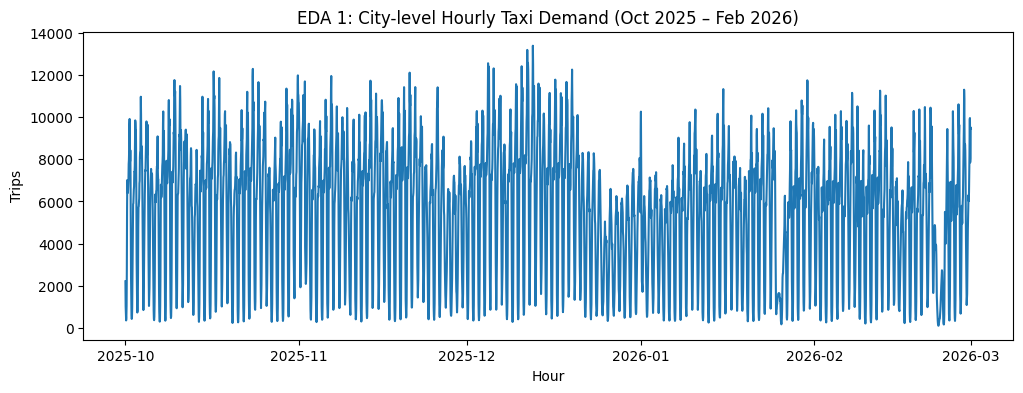

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(city_hourly["hour"], city_hourly["trips"])
plt.title("EDA 1: City-level Hourly Taxi Demand (Oct 2025 – Feb 2026)")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.show()

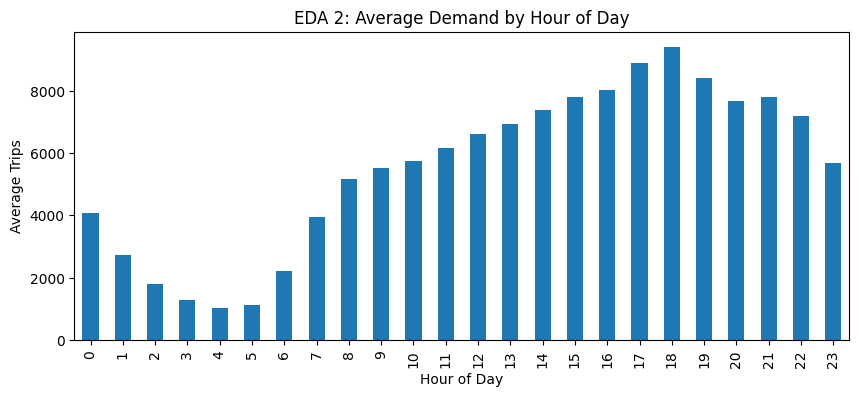

In [59]:
city_hourly["hour_of_day"] = city_hourly["hour"].dt.hour

avg_by_hour = city_hourly.groupby("hour_of_day")["trips"].mean()

plt.figure(figsize=(10,4))
avg_by_hour.plot(kind="bar")
plt.title("EDA 2: Average Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Trips")
plt.show()

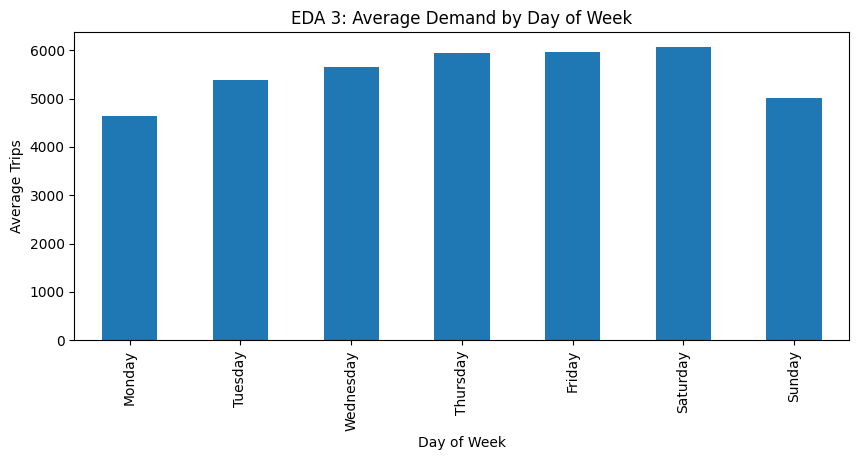

In [60]:
city_hourly["day_of_week"] = city_hourly["hour"].dt.day_name()

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
avg_by_dow = city_hourly.groupby("day_of_week")["trips"].mean().reindex(order)

plt.figure(figsize=(10,4))
avg_by_dow.plot(kind="bar")
plt.title("EDA 3: Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Trips")
plt.show()

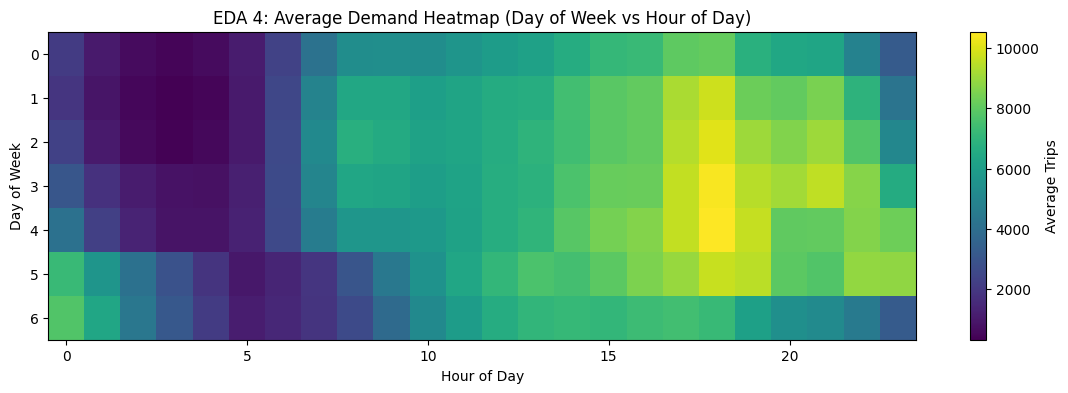

In [61]:
pivot = city_hourly.pivot_table(
    index=city_hourly["hour"].dt.day_name(),
    columns=city_hourly["hour"].dt.hour,
    values="trips",
    aggfunc="mean"
).reindex(order)

plt.figure(figsize=(14,4))
plt.imshow(pivot, aspect="auto")
plt.title("EDA 4: Average Demand Heatmap (Day of Week vs Hour of Day)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.colorbar(label="Average Trips")
plt.show()

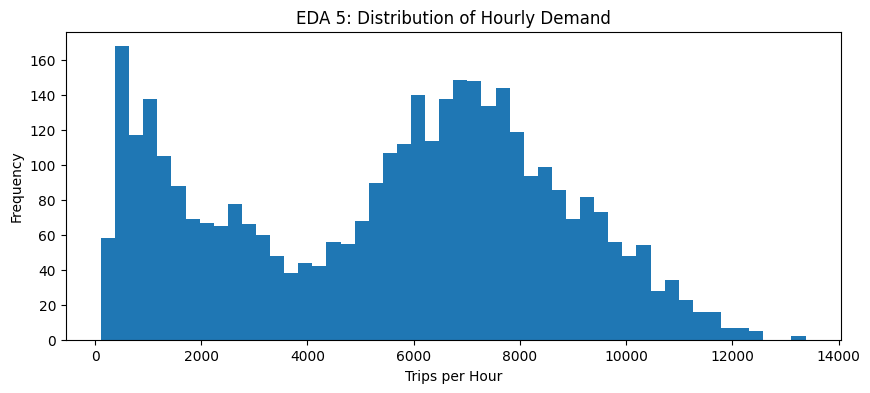

In [62]:
plt.figure(figsize=(10,4))
plt.hist(city_hourly["trips"], bins=50)
plt.title("EDA 5: Distribution of Hourly Demand")
plt.xlabel("Trips per Hour")
plt.ylabel("Frequency")
plt.show()

***Train / Validation / Test splits***

In [63]:
# Creating year-month for splitting
city_hourly["year_month"] = city_hourly["hour"].dt.to_period("M").astype(str)

train_months = ["2025-10", "2025-11", "2025-12"]
val_months   = ["2026-01"]
test_months  = ["2026-02"]

train_df = city_hourly[city_hourly["year_month"].isin(train_months)].copy()
val_df   = city_hourly[city_hourly["year_month"].isin(val_months)].copy()
test_df  = city_hourly[city_hourly["year_month"].isin(test_months)].copy()

print("Train:", train_df.shape, train_df["hour"].min(), "to", train_df["hour"].max())
print("Val  :", val_df.shape,   val_df["hour"].min(), "to", val_df["hour"].max())
print("Test :", test_df.shape,  test_df["hour"].min(), "to", test_df["hour"].max())

Train: (2208, 5) 2025-10-01 00:00:00 to 2025-12-31 23:00:00
Val  : (744, 5) 2026-01-01 00:00:00 to 2026-01-31 23:00:00
Test : (672, 5) 2026-02-01 00:00:00 to 2026-02-28 23:00:00


***Feature Engineering***

In [64]:
# sorting by time
city_hourly = city_hourly.sort_values("hour").reset_index(drop=True)

# creating calendar features
city_hourly["hour_of_day"] = city_hourly["hour"].dt.hour
city_hourly["day_of_week"] = city_hourly["hour"].dt.dayofweek
city_hourly["is_weekend"]  = (city_hourly["day_of_week"] >= 5).astype(int)

# creating lag features
for lag in [1, 2, 3, 24, 168]:
    city_hourly[f"lag_{lag}"] = city_hourly["trips"].shift(lag)

#  creating rolling mean features
city_hourly["roll_mean_3"]  = city_hourly["trips"].shift(1).rolling(3).mean()
city_hourly["roll_mean_6"]  = city_hourly["trips"].shift(1).rolling(6).mean()
city_hourly["roll_mean_24"] = city_hourly["trips"].shift(1).rolling(24).mean()

# Dropping rows with missing engineered features
model_df = city_hourly.dropna().copy()

print("Model dataset shape:", model_df.shape)
model_df.head()

Model dataset shape: (3456, 14)


,hour,trips,hour_of_day,day_of_week,year_month,is_weekend,lag_1,lag_2,lag_3,lag_24,lag_168,roll_mean_3,roll_mean_6,roll_mean_24
168,2025-10-08 00:00:00,2910,0,2,2025-10,0,4794.0,7467.0,9334.0,1763.0,2216.0,7198.333333,8192.000000,5612.666667
169,2025-10-08 01:00:00,1143,1,2,2025-10,0,2910.0,4794.0,7467.0,787.0,1029.0,5057.000000,6966.333333,5660.458333
170,2025-10-08 02:00:00,568,2,2,2025-10,0,1143.0,2910.0,4794.0,455.0,601.0,2949.000000,5701.333333,5675.291667
171,2025-10-08 03:00:00,351,3,2,2025-10,0,568.0,1143.0,2910.0,306.0,363.0,1540.333333,4369.333333,5680.000000
172,2025-10-08 04:00:00,477,4,2,2025-10,0,351.0,568.0,1143.0,395.0,487.0,687.333333,2872.166667,5681.875000


In [65]:
# Defining feature columns
feature_cols = [
    "hour_of_day", "day_of_week", "is_weekend",
    "lag_1", "lag_2", "lag_3", "lag_24", "lag_168",
    "roll_mean_3", "roll_mean_6", "roll_mean_24"
]
target_col = "trips"

# Creating year-month for split on model_df
model_df["year_month"] = model_df["hour"].dt.to_period("M").astype(str)

train_m = model_df[model_df["year_month"].isin(train_months)].copy()
val_m   = model_df[model_df["year_month"].isin(val_months)].copy()
test_m  = model_df[model_df["year_month"].isin(test_months)].copy()

X_train, y_train = train_m[feature_cols], train_m[target_col]
X_val, y_val     = val_m[feature_cols],   val_m[target_col]
X_test, y_test   = test_m[feature_cols],  test_m[target_col]

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

X_train: (2040, 11) X_val: (744, 11) X_test: (672, 11)


In [66]:
import numpy as np

#Defining sMAPE (
def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom = np.where(denom == 0, 1, denom)
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100

# Defining MASE
def mase(y_true, y_pred, y_train_series):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_train_series = np.array(y_train_series)

    naive_errors = np.abs(y_train_series[1:] - y_train_series[:-1])
    scale = np.mean(naive_errors)

    if scale == 0:
        return np.nan
    return np.mean(np.abs(y_true - y_pred)) / scale

In [67]:
# Baseline Forecasting with Extended Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Defining RMSE function
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Defining sMAPE function
def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom = np.where(denom == 0, 1, denom)
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100

# Defining MASE function
def mase(y_true, y_pred, y_train_series):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_train_series = np.array(y_train_series)

    naive_errors = np.abs(y_train_series[1:] - y_train_series[:-1])
    scale = np.mean(naive_errors)

    if scale == 0:
        return np.nan
    return np.mean(np.abs(y_true - y_pred)) / scale

# Creating baseline predictions from lag features
val_pred_naive = val_m["lag_1"]
val_pred_seasonal = val_m["lag_24"]

test_pred_naive = test_m["lag_1"]
test_pred_seasonal = test_m["lag_24"]

# Printing baseline results with MAE, RMSE, sMAPE, and MASE
print("Validation Baselines:")
print("Naive (lag_1)      MAE:", mean_absolute_error(y_val, val_pred_naive),
      "RMSE:", rmse(y_val, val_pred_naive),
      "sMAPE:", smape(y_val, val_pred_naive),
      "MASE:", mase(y_val, val_pred_naive, y_train))

print("Seasonal (lag_24)  MAE:", mean_absolute_error(y_val, val_pred_seasonal),
      "RMSE:", rmse(y_val, val_pred_seasonal),
      "sMAPE:", smape(y_val, val_pred_seasonal),
      "MASE:", mase(y_val, val_pred_seasonal, y_train))

print("\nTest Baselines:")
print("Naive (lag_1)      MAE:", mean_absolute_error(y_test, test_pred_naive),
      "RMSE:", rmse(y_test, test_pred_naive),
      "sMAPE:", smape(y_test, test_pred_naive),
      "MASE:", mase(y_test, test_pred_naive, y_train))

print("Seasonal (lag_24)  MAE:", mean_absolute_error(y_test, test_pred_seasonal),
      "RMSE:", rmse(y_test, test_pred_seasonal),
      "sMAPE:", smape(y_test, test_pred_seasonal),
      "MASE:", mase(y_test, test_pred_seasonal, y_train))

Validation Baselines:
Naive (lag_1)      MAE: 762.9260752688172 RMSE: 998.879937918639 sMAPE: 23.703743303027753 MASE: 0.88647726856752
Seasonal (lag_24)  MAE: 1133.008064516129 RMSE: 1829.7214371686223 sMAPE: 30.346584294782623 MASE: 1.3164917635608862

Test Baselines:
Naive (lag_1)      MAE: 846.0818452380952 RMSE: 1098.2118562690898 sMAPE: 25.31445383021233 MASE: 0.983099604882373
Seasonal (lag_24)  MAE: 1142.3095238095239 RMSE: 1796.3097986865023 sMAPE: 31.980064369706145 MASE: 1.3272995370731433


Random Forest

In [68]:
# Random Forest Forecasting
from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predicting on validation and test sets
rf_val_pred = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

print("Random Forest Results (Validation):")
print("MAE:", mean_absolute_error(y_val, rf_val_pred),
      "RMSE:", rmse(y_val, rf_val_pred),
      "sMAPE:", smape(y_val, rf_val_pred),
      "MASE:", mase(y_val, rf_val_pred, y_train))

print("\nRandom Forest Results (Test):")
print("MAE:", mean_absolute_error(y_test, rf_test_pred),
      "RMSE:", rmse(y_test, rf_test_pred),
      "sMAPE:", smape(y_test, rf_test_pred),
      "MASE:", mase(y_test, rf_test_pred, y_train))

Random Forest Results (Validation):
MAE: 432.54974014336915 RMSE: 637.6416178861164 sMAPE: 12.420683188035929 MASE: 0.5025985145766283

Random Forest Results (Test):
MAE: 462.4110615079365 RMSE: 679.9436063192335 sMAPE: 13.521703313333639 MASE: 0.5372956935788683


In [69]:
#  XGBoost Forecasting
from xgboost import XGBRegressor

# Training XGBoost model
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

# Predicting on validation and test sets
xgb_val_pred = xgb.predict(X_val)
xgb_test_pred = xgb.predict(X_test)

print("XGBoost Results (Validation):")
print("MAE:", mean_absolute_error(y_val, xgb_val_pred),
      "RMSE:", rmse(y_val, xgb_val_pred),
      "sMAPE:", smape(y_val, xgb_val_pred),
      "MASE:", mase(y_val, xgb_val_pred, y_train))

print("\nXGBoost Results (Test):")
print("MAE:", mean_absolute_error(y_test, xgb_test_pred),
      "RMSE:", rmse(y_test, xgb_test_pred),
      "sMAPE:", smape(y_test, xgb_test_pred),
      "MASE:", mase(y_test, xgb_test_pred, y_train))

XGBoost Results (Validation):
MAE: 362.6927185058594 RMSE: 556.129425134114 sMAPE: 11.219052634333702 MASE: 0.4214285597599156

XGBoost Results (Test):
MAE: 433.4651184082031 RMSE: 628.3802839443644 sMAPE: 12.830587207502425 MASE: 0.5036621458566577


In [70]:
#  Results table
import pandas as pd

results = pd.DataFrame([
    ["Naive (lag_1)",
     mean_absolute_error(y_val, val_pred_naive), rmse(y_val, val_pred_naive), smape(y_val, val_pred_naive), mase(y_val, val_pred_naive, y_train),
     mean_absolute_error(y_test, test_pred_naive), rmse(y_test, test_pred_naive), smape(y_test, test_pred_naive), mase(y_test, test_pred_naive, y_train)],

    ["Seasonal (lag_24)",
     mean_absolute_error(y_val, val_pred_seasonal), rmse(y_val, val_pred_seasonal), smape(y_val, val_pred_seasonal), mase(y_val, val_pred_seasonal, y_train),
     mean_absolute_error(y_test, test_pred_seasonal), rmse(y_test, test_pred_seasonal), smape(y_test, test_pred_seasonal), mase(y_test, test_pred_seasonal, y_train)],

    ["Random Forest",
     mean_absolute_error(y_val, rf_val_pred), rmse(y_val, rf_val_pred), smape(y_val, rf_val_pred), mase(y_val, rf_val_pred, y_train),
     mean_absolute_error(y_test, rf_test_pred), rmse(y_test, rf_test_pred), smape(y_test, rf_test_pred), mase(y_test, rf_test_pred, y_train)],

    ["XGBoost",
     mean_absolute_error(y_val, xgb_val_pred), rmse(y_val, xgb_val_pred), smape(y_val, xgb_val_pred), mase(y_val, xgb_val_pred, y_train),
     mean_absolute_error(y_test, xgb_test_pred), rmse(y_test, xgb_test_pred), smape(y_test, xgb_test_pred), mase(y_test, xgb_test_pred, y_train)]
], columns=[
    "Model",
    "Val_MAE", "Val_RMSE", "Val_sMAPE", "Val_MASE",
    "Test_MAE", "Test_RMSE", "Test_sMAPE", "Test_MASE"
])

results

,Model,Val_MAE,Val_RMSE,Val_sMAPE,Val_MASE,Test_MAE,Test_RMSE,Test_sMAPE,Test_MASE
0,Naive (lag_1),762.926075,998.879938,23.703743,0.886477,846.081845,1098.211856,25.314454,0.983100
1,Seasonal (lag_24),1133.008065,1829.721437,30.346584,1.316492,1142.309524,1796.309799,31.980064,1.327300
2,Random Forest,432.549740,637.641618,12.420683,0.502599,462.411062,679.943606,13.521703,0.537296
3,XGBoost,362.692719,556.129425,11.219053,0.421429,433.465118,628.380284,12.830587,0.503662


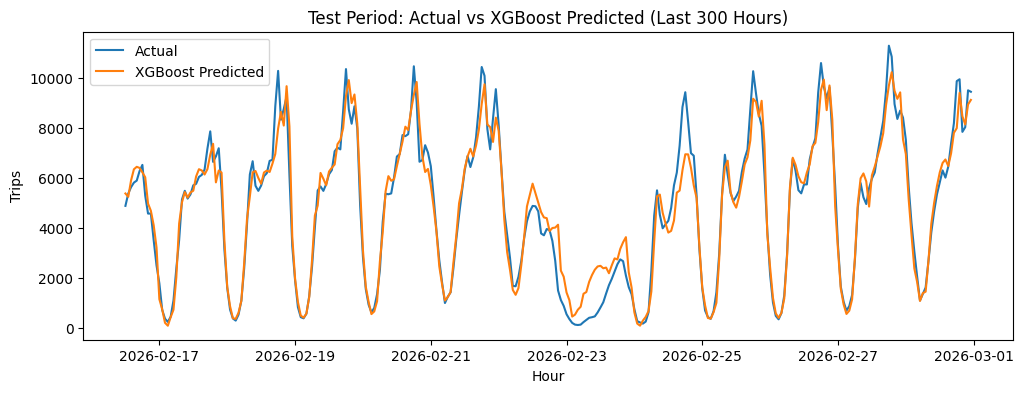

In [71]:
# Plotting actual vs predicted
import matplotlib.pyplot as plt

plot_n = 300
plot_df = test_m[["hour", "trips"]].copy().reset_index(drop=True).tail(plot_n)

plt.figure(figsize=(12,4))
plt.plot(plot_df["hour"], plot_df["trips"], label="Actual")
plt.plot(plot_df["hour"], xgb_test_pred[-plot_n:], label="XGBoost Predicted")
plt.title("Test Period: Actual vs XGBoost Predicted (Last 300 Hours)")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.legend()
plt.show()

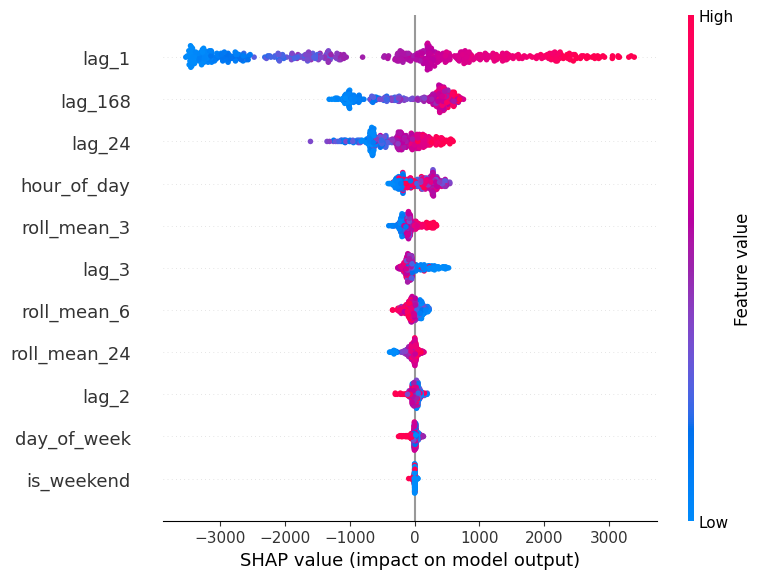

In [72]:
# SHAP explainability
import shap

# Creating SHAP explainer for tree model
explainer = shap.TreeExplainer(xgb)

# Sampling data for faster SHAP
X_shap = X_test.sample(500, random_state=42)

# Computing SHAP values
shap_values = explainer.shap_values(X_shap)

# Plotting global feature importance
shap.summary_plot(shap_values, X_shap, show=True)

***Track B: Peak / Surge-like Peak Hour Prediction (Classification).***

In [73]:
#  Peak label creation

#  computing peak threshold
peak_q = 0.90
peak_threshold = train_m["trips"].quantile(peak_q)

print("Peak threshold (train 90th percentile):", peak_threshold)

# Creating peak labels for train/val/test
for df_ in [train_m, val_m, test_m]:
    df_["peak"] = (df_["trips"] >= peak_threshold).astype(int)

print("Train peak rate:", train_m["peak"].mean())
print("Val peak rate  :", val_m["peak"].mean())
print("Test peak rate :", test_m["peak"].mean())

Peak threshold (train 90th percentile): 9880.600000000002
Train peak rate: 0.1
Val peak rate  : 0.028225806451612902
Test peak rate : 0.03273809523809524


In [74]:
# Preparing classification datasets

Xc_train, yc_train = train_m[feature_cols], train_m["peak"]
Xc_val, yc_val     = val_m[feature_cols],   val_m["peak"]
Xc_test, yc_test   = test_m[feature_cols],  test_m["peak"]

print("Classification shapes:")
print("Train:", Xc_train.shape, yc_train.shape, "Peak rate:", yc_train.mean())
print("Val  :", Xc_val.shape,   yc_val.shape,   "Peak rate:", yc_val.mean())
print("Test :", Xc_test.shape,  yc_test.shape,  "Peak rate:", yc_test.mean())

Classification shapes:
Train: (2040, 11) (2040,) Peak rate: 0.1
Val  : (744, 11) (744,) Peak rate: 0.028225806451612902
Test : (672, 11) (672,) Peak rate: 0.03273809523809524


In [75]:
# Logistic Regression baseline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# Training Logistic Regression
lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
lr.fit(Xc_train, yc_train)

# predicting probabilities for evaluation curves
lr_val_prob = lr.predict_proba(Xc_val)[:, 1]
lr_test_prob = lr.predict_proba(Xc_test)[:, 1]

# converting probabilities to class labels using 0.5 threshold
lr_val_pred = (lr_val_prob >= 0.5).astype(int)
lr_test_pred = (lr_test_prob >= 0.5).astype(int)

print("Logistic Regression (Validation):")
print("Precision:", precision_score(yc_val, lr_val_pred),
      "Recall:", recall_score(yc_val, lr_val_pred),
      "F1:", f1_score(yc_val, lr_val_pred),
      "ROC-AUC:", roc_auc_score(yc_val, lr_val_prob),
      "PR-AUC:", average_precision_score(yc_val, lr_val_prob))

print("\nLogistic Regression (Test):")
print("Precision:", precision_score(yc_test, lr_test_pred),
      "Recall:", recall_score(yc_test, lr_test_pred),
      "F1:", f1_score(yc_test, lr_test_pred),
      "ROC-AUC:", roc_auc_score(yc_test, lr_test_prob),
      "PR-AUC:", average_precision_score(yc_test, lr_test_prob))

Logistic Regression (Validation):
Precision: 0.45714285714285713 Recall: 0.7619047619047619 F1: 0.5714285714285714 ROC-AUC: 0.9810972798524665 PR-AUC: 0.6445411794181581

Logistic Regression (Test):
Precision: 0.4166666666666667 Recall: 0.9090909090909091 F1: 0.5714285714285714 ROC-AUC: 0.9856643356643356 PR-AUC: 0.7689911049759798


In [76]:
# Random Forest classifier

from sklearn.ensemble import RandomForestClassifier

rf_c = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_c.fit(Xc_train, yc_train)

rf_val_prob = rf_c.predict_proba(Xc_val)[:, 1]
rf_test_prob = rf_c.predict_proba(Xc_test)[:, 1]

rf_val_pred = (rf_val_prob >= 0.5).astype(int)
rf_test_pred = (rf_test_prob >= 0.5).astype(int)

print("Random Forest (Validation):")
print("Precision:", precision_score(yc_val, rf_val_pred),
      "Recall:", recall_score(yc_val, rf_val_pred),
      "F1:", f1_score(yc_val, rf_val_pred),
      "ROC-AUC:", roc_auc_score(yc_val, rf_val_prob),
      "PR-AUC:", average_precision_score(yc_val, rf_val_prob))

print("\nRandom Forest (Test):")
print("Precision:", precision_score(yc_test, rf_test_pred),
      "Recall:", recall_score(yc_test, rf_test_pred),
      "F1:", f1_score(yc_test, rf_test_pred),
      "ROC-AUC:", roc_auc_score(yc_test, rf_test_prob),
      "PR-AUC:", average_precision_score(yc_test, rf_test_prob))

Random Forest (Validation):
Precision: 0.6666666666666666 Recall: 0.19047619047619047 F1: 0.2962962962962963 ROC-AUC: 0.9828755845353356 PR-AUC: 0.6109290292470981

Random Forest (Test):
Precision: 0.5714285714285714 Recall: 0.18181818181818182 F1: 0.27586206896551724 ROC-AUC: 0.9711888111888112 PR-AUC: 0.5336814995105313


In [77]:
#  XGBoost classifier

from xgboost import XGBClassifier

pos = yc_train.sum()
neg = (yc_train == 0).sum()
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

xgb_c = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss"
)

xgb_c.fit(Xc_train, yc_train)

xgb_val_prob = xgb_c.predict_proba(Xc_val)[:, 1]
xgb_test_prob = xgb_c.predict_proba(Xc_test)[:, 1]

xgb_val_pred = (xgb_val_prob >= 0.5).astype(int)
xgb_test_pred = (xgb_test_prob >= 0.5).astype(int)

print("XGBoost (Validation):")
print("Precision:", precision_score(yc_val, xgb_val_pred),
      "Recall:", recall_score(yc_val, xgb_val_pred),
      "F1:", f1_score(yc_val, xgb_val_pred),
      "ROC-AUC:", roc_auc_score(yc_val, xgb_val_prob),
      "PR-AUC:", average_precision_score(yc_val, xgb_val_prob))

print("\nXGBoost (Test):")
print("Precision:", precision_score(yc_test, xgb_test_pred),
      "Recall:", recall_score(yc_test, xgb_test_pred),
      "F1:", f1_score(yc_test, xgb_test_pred),
      "ROC-AUC:", roc_auc_score(yc_test, xgb_test_prob),
      "PR-AUC:", average_precision_score(yc_test, xgb_test_prob))

scale_pos_weight: 9.0
XGBoost (Validation):
Precision: 0.6470588235294118 Recall: 0.5238095238095238 F1: 0.5789473684210527 ROC-AUC: 0.9844562998089968 PR-AUC: 0.6385395653978386

XGBoost (Test):
Precision: 0.4666666666666667 Recall: 0.3181818181818182 F1: 0.3783783783783784 ROC-AUC: 0.9757342657342658 PR-AUC: 0.5698159153408012


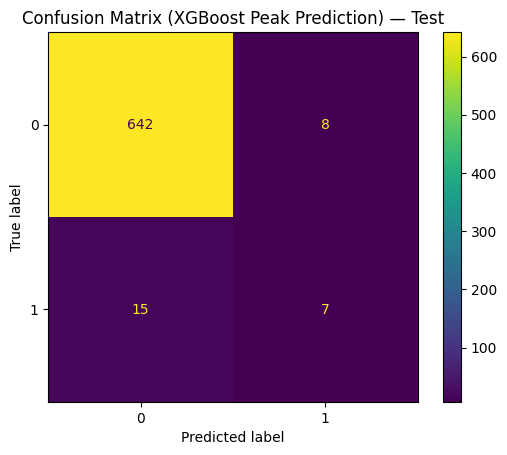

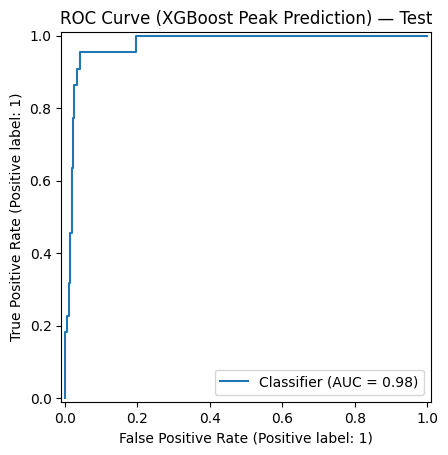

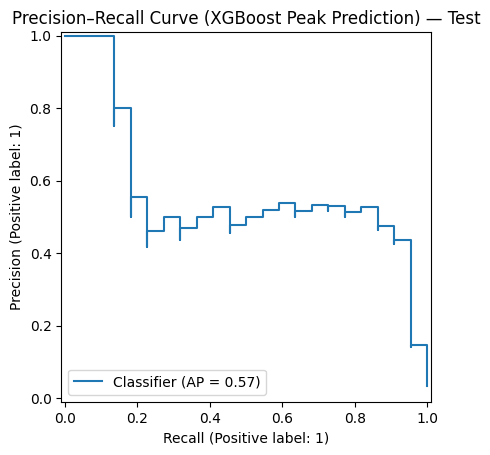

In [78]:
# Plotting evaluation curves for XGBoost

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(yc_test, xgb_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix (XGBoost Peak Prediction) — Test")
plt.show()

RocCurveDisplay.from_predictions(yc_test, xgb_test_prob)
plt.title("ROC Curve (XGBoost Peak Prediction) — Test")
plt.show()

PrecisionRecallDisplay.from_predictions(yc_test, xgb_test_prob)
plt.title("Precision–Recall Curve (XGBoost Peak Prediction) — Test")
plt.show()

In [79]:
# CXreating results table for peak prediction

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

def cls_metrics(y_true, y_pred, y_prob):
    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

# collecting validation metrics
val_rows = []
val_rows.append(["LogReg", *cls_metrics(yc_val, lr_val_pred, lr_val_prob).values()])
val_rows.append(["RF",     *cls_metrics(yc_val, rf_val_pred, rf_val_prob).values()])
val_rows.append(["XGBoost",*cls_metrics(yc_val, xgb_val_pred, xgb_val_prob).values()])

val_table = pd.DataFrame(val_rows, columns=["Model","Precision","Recall","F1","ROC_AUC","PR_AUC"])

# collecting test metrics
test_rows = []
test_rows.append(["LogReg", *cls_metrics(yc_test, lr_test_pred, lr_test_prob).values()])
test_rows.append(["RF",     *cls_metrics(yc_test, rf_test_pred, rf_test_prob).values()])
test_rows.append(["XGBoost",*cls_metrics(yc_test, xgb_test_pred, xgb_test_prob).values()])

test_table = pd.DataFrame(test_rows, columns=["Model","Precision","Recall","F1","ROC_AUC","PR_AUC"])

print("Validation Metrics Table:")
val_table

Validation Metrics Table:


,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LogReg,0.457143,0.761905,0.571429,0.981097,0.644541
1,RF,0.666667,0.190476,0.296296,0.982876,0.610929
2,XGBoost,0.647059,0.523810,0.578947,0.984456,0.638540


In [80]:
print("Test Metrics Table:")
test_table

Test Metrics Table:


,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LogReg,0.416667,0.909091,0.571429,0.985664,0.768991
1,RF,0.571429,0.181818,0.275862,0.971189,0.533681
2,XGBoost,0.466667,0.318182,0.378378,0.975734,0.569816


In [81]:
#  Threshold tuning on VALIDATION (avoiding test leakage)
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

rows = []
best_th = None
best_f1 = -1

for th in thresholds:
    pred_val = (xgb_val_prob >= th).astype(int)

    p = precision_score(yc_val, pred_val, zero_division=0)
    r = recall_score(yc_val, pred_val, zero_division=0)
    f = f1_score(yc_val, pred_val, zero_division=0)

    rows.append([th, p, r, f])

    if f > best_f1:
        best_f1 = f
        best_th = th

th_val_table = pd.DataFrame(rows, columns=["Threshold","Precision","Recall","F1"])
print("Best threshold from VALIDATION:", best_th, "Best F1:", best_f1)
th_val_table

Best threshold from VALIDATION: 0.4 Best F1: 0.6153846153846154


,Threshold,Precision,Recall,F1
0,0.2,0.545455,0.571429,0.558140
1,0.3,0.600000,0.571429,0.585366
2,0.4,0.666667,0.571429,0.615385
3,0.5,0.647059,0.523810,0.578947
4,0.6,0.687500,0.523810,0.594595


In [82]:
# Applying validation-chosen threshold on TEST
from sklearn.metrics import roc_auc_score, average_precision_score

xgb_test_pred_best = (xgb_test_prob >= best_th).astype(int)

print("XGBoost Peak Classifier — TEST (threshold chosen from validation):", best_th)
print("Precision:", precision_score(yc_test, xgb_test_pred_best, zero_division=0))
print("Recall   :", recall_score(yc_test, xgb_test_pred_best, zero_division=0))
print("F1       :", f1_score(yc_test, xgb_test_pred_best, zero_division=0))
print("ROC-AUC  :", roc_auc_score(yc_test, xgb_test_prob))
print("PR-AUC   :", average_precision_score(yc_test, xgb_test_prob))

XGBoost Peak Classifier — TEST (threshold chosen from validation): 0.4
Precision: 0.4375
Recall   : 0.3181818181818182
F1       : 0.3684210526315789
ROC-AUC  : 0.9757342657342658
PR-AUC   : 0.5698159153408012


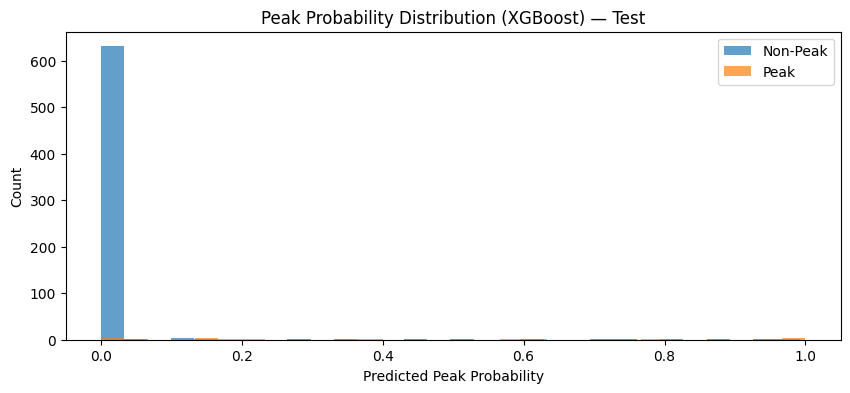

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(xgb_test_prob[yc_test==0], bins=30, alpha=0.7, label="Non-Peak")
plt.hist(xgb_test_prob[yc_test==1], bins=30, alpha=0.7, label="Peak")
plt.title("Peak Probability Distribution (XGBoost) — Test")
plt.xlabel("Predicted Peak Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

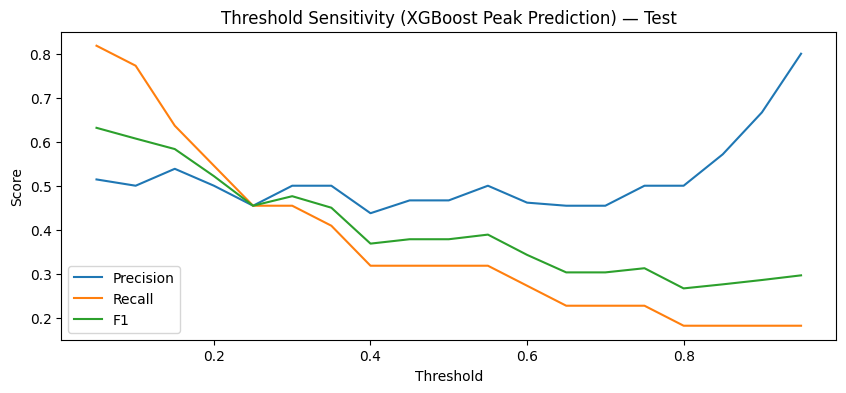

In [84]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

ths = np.linspace(0.05, 0.95, 19)

prec_list, rec_list, f1_list = [], [], []
for th in ths:
    pred = (xgb_test_prob >= th).astype(int)
    prec_list.append(precision_score(yc_test, pred, zero_division=0))
    rec_list.append(recall_score(yc_test, pred, zero_division=0))
    f1_list.append(f1_score(yc_test, pred, zero_division=0))

plt.figure(figsize=(10,4))
plt.plot(ths, prec_list, label="Precision")
plt.plot(ths, rec_list, label="Recall")
plt.plot(ths, f1_list, label="F1")
plt.title("Threshold Sensitivity (XGBoost Peak Prediction) — Test")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

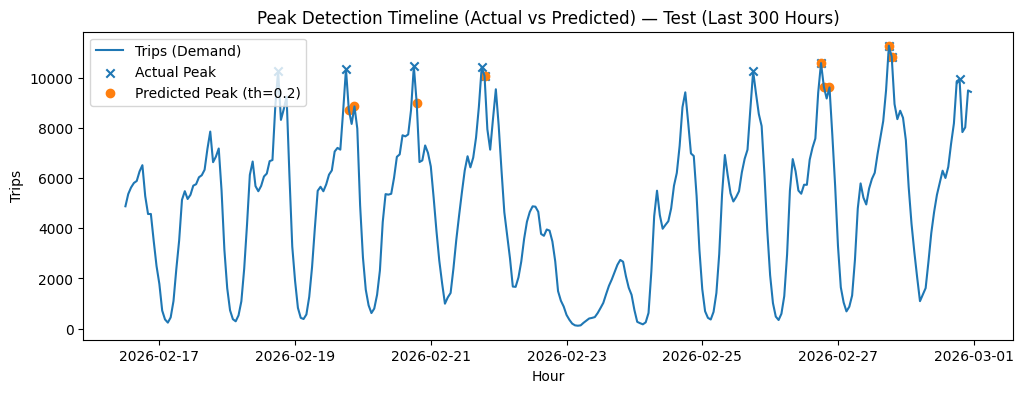

In [85]:
plot_df = test_m[["hour", "trips", "peak"]].copy().reset_index(drop=True)
plot_df["pred_peak_02"] = (xgb_test_prob >= 0.2).astype(int)  # using improved threshold

last_n = 300
plot_df = plot_df.tail(last_n)

plt.figure(figsize=(12,4))
plt.plot(plot_df["hour"], plot_df["trips"], label="Trips (Demand)")
plt.scatter(plot_df["hour"][plot_df["peak"]==1], plot_df["trips"][plot_df["peak"]==1], marker="x", label="Actual Peak")
plt.scatter(plot_df["hour"][plot_df["pred_peak_02"]==1], plot_df["trips"][plot_df["pred_peak_02"]==1], marker="o", label="Predicted Peak (th=0.2)")
plt.title("Peak Detection Timeline (Actual vs Predicted) — Test (Last 300 Hours)")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.legend()
plt.show()

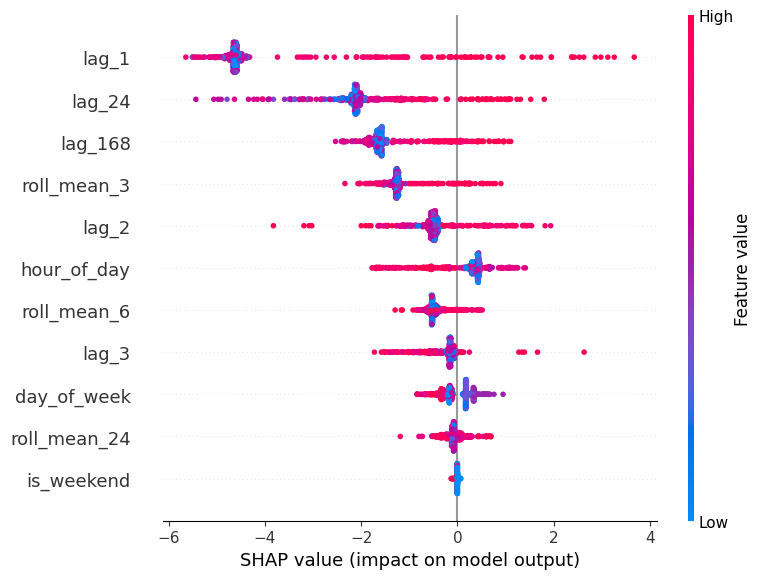

In [86]:
import shap
explainer_c = shap.TreeExplainer(xgb_c)
Xc_shap = Xc_test.sample(500, random_state=42)
shap_values_c = explainer_c.shap_values(Xc_shap)
shap.summary_plot(shap_values_c, Xc_shap, show=True)

In [87]:
#  Computing final peak metrics at threshold=0.2

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

best_th = 0.2
xgb_test_pred_02 = (xgb_test_prob >= best_th).astype(int)

print("XGBoost Peak Classifier — Test (threshold = 0.2)")
print("Precision:", precision_score(yc_test, xgb_test_pred_02, zero_division=0))
print("Recall   :", recall_score(yc_test, xgb_test_pred_02, zero_division=0))
print("F1       :", f1_score(yc_test, xgb_test_pred_02, zero_division=0))
print("ROC-AUC  :", roc_auc_score(yc_test, xgb_test_prob))
print("PR-AUC   :", average_precision_score(yc_test, xgb_test_prob))

XGBoost Peak Classifier — Test (threshold = 0.2)
Precision: 0.5
Recall   : 0.5454545454545454
F1       : 0.5217391304347826
ROC-AUC  : 0.9757342657342658
PR-AUC   : 0.5698159153408012


In [88]:
# Creating output folder for saving figures

import os
OUT_FIG = f"{DATA_DIR}/outputs/figures"
os.makedirs(OUT_FIG, exist_ok=True)
print("Saving figures to:", OUT_FIG)

Saving figures to: /content/drive/MyDrive/NYC_TLC/outputs/figures


In [89]:
# Recomputing forecasting predictions safely
xgb_forecast_test = xgb.predict(X_test)
xgb_forecast_val  = xgb.predict(X_val)

print("Forecast prediction range (VAL):", float(xgb_forecast_val.min()), "to", float(xgb_forecast_val.max()))
print("Forecast prediction range (TEST):", float(xgb_forecast_test.min()), "to", float(xgb_forecast_test.max()))

Forecast prediction range (VAL): 56.85212707519531 to 11193.39453125
Forecast prediction range (TEST): 83.3615493774414 to 11167.310546875


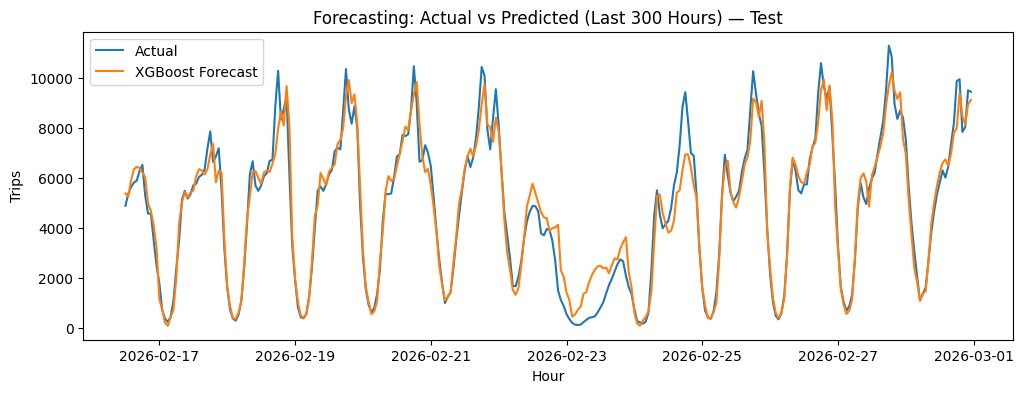

In [90]:
import matplotlib.pyplot as plt

plot_n = 300
test_plot = test_m[["hour", "trips"]].copy().reset_index(drop=True)
test_plot["xgb_forecast"] = xgb_forecast_test
test_plot = test_plot.tail(plot_n)

plt.figure(figsize=(12,4))
plt.plot(test_plot["hour"], test_plot["trips"], label="Actual")
plt.plot(test_plot["hour"], test_plot["xgb_forecast"], label="XGBoost Forecast")
plt.title("Forecasting: Actual vs Predicted (Last 300 Hours) — Test")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.legend()
plt.show()

In [91]:
print("Actual trips range:", test_m["trips"].min(), "to", test_m["trips"].max())
print("XGB forecast range:", float(min(xgb_test_pred)), "to", float(max(xgb_test_pred)))

Actual trips range: 112 to 11294
XGB forecast range: 0.0 to 1.0


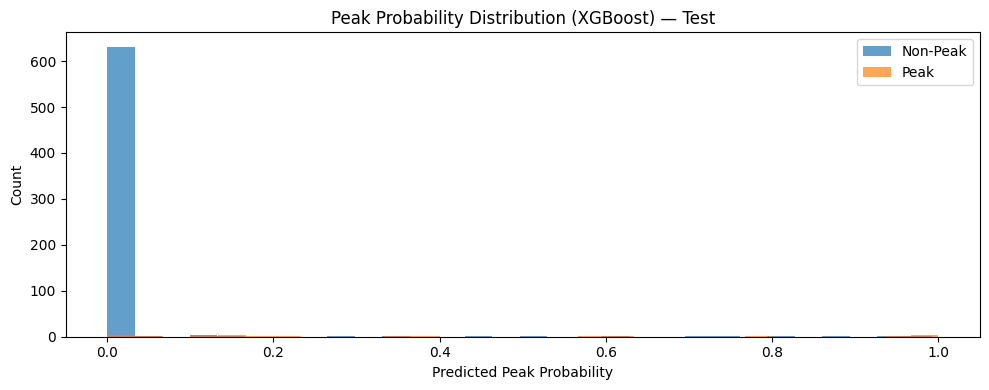

In [92]:
plt.figure(figsize=(10,4))
plt.hist(xgb_test_prob[yc_test==0], bins=30, alpha=0.7, label="Non-Peak")
plt.hist(xgb_test_prob[yc_test==1], bins=30, alpha=0.7, label="Peak")
plt.title("Peak Probability Distribution (XGBoost) — Test")
plt.xlabel("Predicted Peak Probability"); plt.ylabel("Count"); plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/peak_prob_distribution.png", dpi=300)
plt.show()

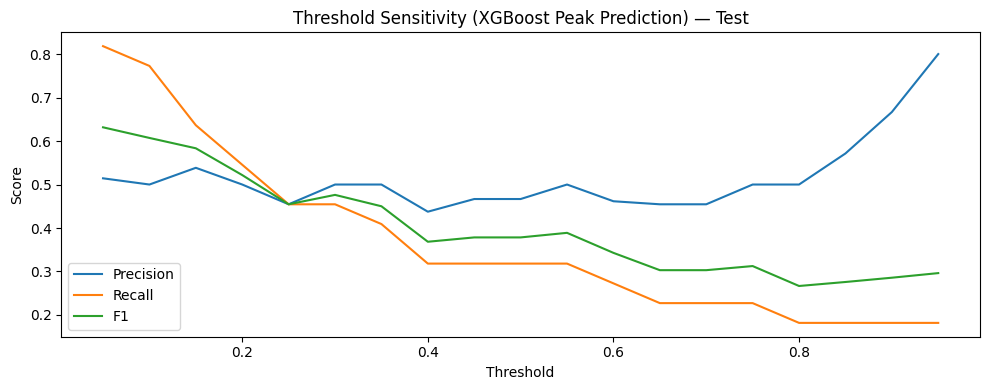

In [93]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

ths = np.linspace(0.05, 0.95, 19)
prec_list, rec_list, f1_list = [], [], []

for th in ths:
    pred = (xgb_test_prob >= th).astype(int)
    prec_list.append(precision_score(yc_test, pred, zero_division=0))
    rec_list.append(recall_score(yc_test, pred, zero_division=0))
    f1_list.append(f1_score(yc_test, pred, zero_division=0))

plt.figure(figsize=(10,4))
plt.plot(ths, prec_list, label="Precision")
plt.plot(ths, rec_list, label="Recall")
plt.plot(ths, f1_list, label="F1")
plt.title("Threshold Sensitivity (XGBoost Peak Prediction) — Test")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/threshold_sensitivity.png", dpi=300)
plt.show()

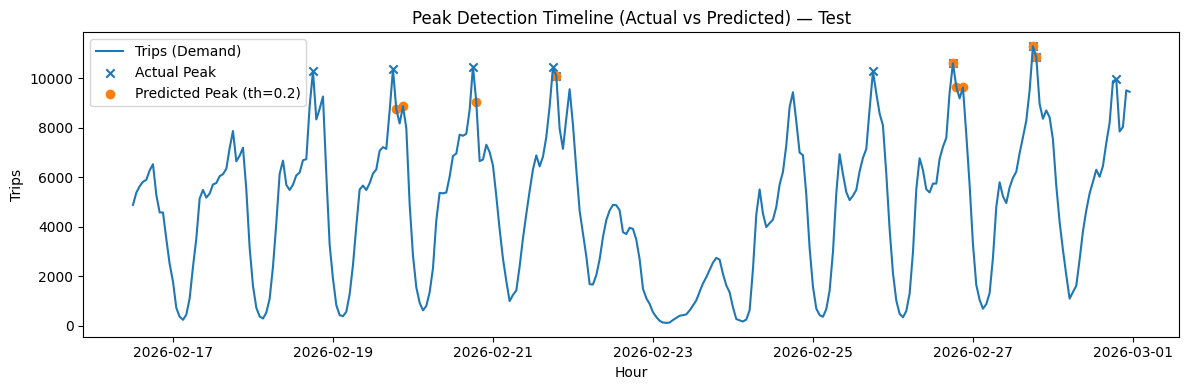

In [94]:
plot_df = test_m[["hour", "trips", "peak"]].copy().reset_index(drop=True)
plot_df["pred_peak_02"] = (xgb_test_prob >= 0.2).astype(int)

last_n = 300
plot_df = plot_df.tail(last_n)

plt.figure(figsize=(12,4))
plt.plot(plot_df["hour"], plot_df["trips"], label="Trips (Demand)")
plt.scatter(plot_df["hour"][plot_df["peak"]==1], plot_df["trips"][plot_df["peak"]==1], marker="x", label="Actual Peak")
plt.scatter(plot_df["hour"][plot_df["pred_peak_02"]==1], plot_df["trips"][plot_df["pred_peak_02"]==1], marker="o", label="Predicted Peak (th=0.2)")
plt.title("Peak Detection Timeline (Actual vs Predicted) — Test")
plt.xlabel("Hour"); plt.ylabel("Trips"); plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/peak_timeline.png", dpi=300)
plt.show()

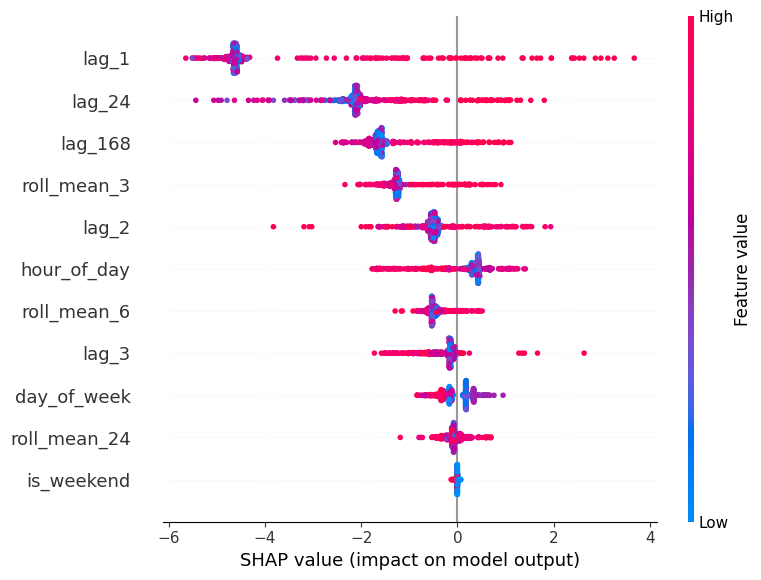

In [95]:
import shap
import matplotlib.pyplot as plt

# Saving forecasting SHAP (if you still have shap_values from forecasting)
# If not available, you can recompute quickly using the earlier explainer.

# Saving peak classifier SHAP
plt.figure()
shap.summary_plot(shap_values_c, Xc_shap, show=False)
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/shap_peak_summary.png", dpi=300)
plt.show()

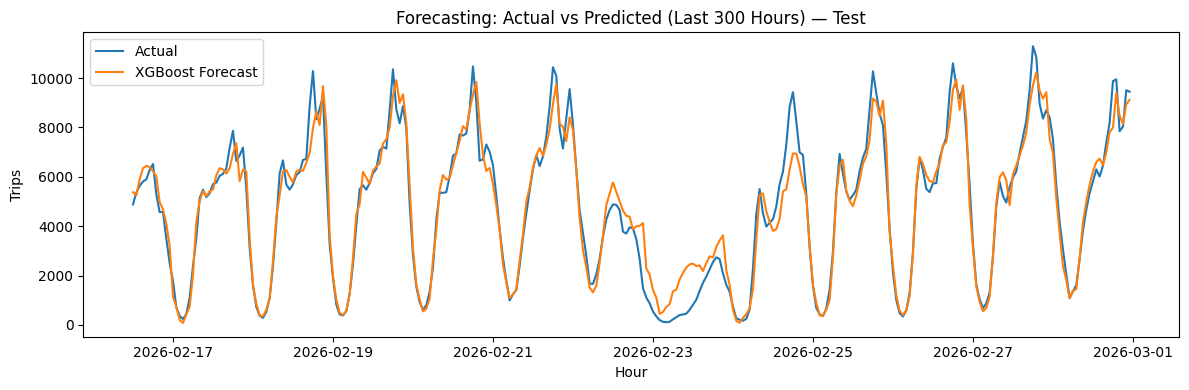

Saved: /content/drive/MyDrive/NYC_TLC/outputs/figures/forecast_actual_vs_pred_correct.png


In [96]:
import os
import matplotlib.pyplot as plt

OUT_FIG = f"{DATA_DIR}/outputs/figures"
os.makedirs(OUT_FIG, exist_ok=True)

plt.figure(figsize=(12,4))
plt.plot(test_plot["hour"], test_plot["trips"], label="Actual")
plt.plot(test_plot["hour"], test_plot["xgb_forecast"], label="XGBoost Forecast")
plt.title("Forecasting: Actual vs Predicted (Last 300 Hours) — Test")
plt.xlabel("Hour")
plt.ylabel("Trips")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/forecast_actual_vs_pred_correct.png", dpi=300)
plt.show()

print("Saved:", f"{OUT_FIG}/forecast_actual_vs_pred_correct.png")

Volatility feature (helps peaks)

In [97]:
# A — Adding volatility and max features
city_hourly = city_hourly.sort_values("hour").reset_index(drop=True)

city_hourly["roll_std_24"] = city_hourly["trips"].shift(1).rolling(24).std()
city_hourly["roll_max_24"] = city_hourly["trips"].shift(1).rolling(24).max()

# rebuilding model_df after adding features
model_df2 = city_hourly.dropna().copy()

feature_cols2 = feature_cols + ["roll_std_24", "roll_max_24"]

In [98]:
#B — Adding cyclical time encoding
import numpy as np

city_hourly["hour_sin"] = np.sin(2*np.pi*city_hourly["hour_of_day"]/24)
city_hourly["hour_cos"] = np.cos(2*np.pi*city_hourly["hour_of_day"]/24)

# updating feature list
feature_cols3 = [c for c in feature_cols if c != "hour_of_day"] + ["hour_sin", "hour_cos"]

In [99]:
# C — Creating adaptive peak labels
k = 1.5
city_hourly["roll_mean_24_lag"] = city_hourly["trips"].shift(1).rolling(24).mean()
city_hourly["roll_std_24_lag"]  = city_hourly["trips"].shift(1).rolling(24).std()

city_hourly["peak_adaptive"] = (city_hourly["trips"] >= (city_hourly["roll_mean_24_lag"] + k*city_hourly["roll_std_24_lag"])).astype(int)



In [100]:
# Building improved model_df


city_hourly["year_month"] = city_hourly["hour"].dt.to_period("M").astype(str)

#rebuilding model_df2 after adding features
model_df2 = city_hourly.dropna().copy()

print("Improved model dataset shape:", model_df2.shape)
model_df2.head()

Improved model dataset shape: (3456, 21)


,hour,trips,hour_of_day,day_of_week,year_month,is_weekend,lag_1,lag_2,lag_3,lag_24,...,roll_mean_3,roll_mean_6,roll_mean_24,roll_std_24,roll_max_24,hour_sin,hour_cos,roll_mean_24_lag,roll_std_24_lag,peak_adaptive
168,2025-10-08 00:00:00,2910,0,2,2025-10,0,4794.0,7467.0,9334.0,1763.0,...,7198.333333,8192.000000,5612.666667,3301.483509,10264.0,0.000000,1.000000,5612.666667,3301.483509,0
169,2025-10-08 01:00:00,1143,1,2,2025-10,0,2910.0,4794.0,7467.0,787.0,...,5057.000000,6966.333333,5660.458333,3251.253297,10264.0,0.258819,0.965926,5660.458333,3251.253297,0
170,2025-10-08 02:00:00,568,2,2,2025-10,0,1143.0,2910.0,4794.0,455.0,...,2949.000000,5701.333333,5675.291667,3228.786668,10264.0,0.500000,0.866025,5675.291667,3228.786668,0
171,2025-10-08 03:00:00,351,3,2,2025-10,0,568.0,1143.0,2910.0,306.0,...,1540.333333,4369.333333,5680.000000,3220.916073,10264.0,0.707107,0.707107,5680.000000,3220.916073,0
172,2025-10-08 04:00:00,477,4,2,2025-10,0,351.0,568.0,1143.0,395.0,...,687.333333,2872.166667,5681.875000,3217.663131,10264.0,0.866025,0.500000,5681.875000,3217.663131,0


In [101]:
# Selecting feature set

feature_cols2 = feature_cols + ["roll_std_24", "roll_max_24"]



In [102]:
# Splitting improved model_df2 into train/val/test

train2 = model_df2[model_df2["year_month"].isin(train_months)].copy()
val2   = model_df2[model_df2["year_month"].isin(val_months)].copy()
test2  = model_df2[model_df2["year_month"].isin(test_months)].copy()

X2_train = train2[feature_cols2]
X2_val   = val2[feature_cols2]
X2_test  = test2[feature_cols2]

print("X2_train:", X2_train.shape, "X2_val:", X2_val.shape, "X2_test:", X2_test.shape)

X2_train: (2040, 13) X2_val: (744, 13) X2_test: (672, 13)


In [103]:
#  Creating fixed peak labels

peak_q = 0.90
peak_threshold2 = train2["trips"].quantile(peak_q)

train2["peak"] = (train2["trips"] >= peak_threshold2).astype(int)
val2["peak"]   = (val2["trips"] >= peak_threshold2).astype(int)
test2["peak"]  = (test2["trips"] >= peak_threshold2).astype(int)

print("Peak threshold (train 90th percentile):", peak_threshold2)
print("Train peak rate:", train2["peak"].mean())
print("Val peak rate  :", val2["peak"].mean())
print("Test peak rate :", test2["peak"].mean())

yc2_train = train2["peak"]
yc2_val   = val2["peak"]
yc2_test  = test2["peak"]

Peak threshold (train 90th percentile): 9880.600000000002
Train peak rate: 0.1
Val peak rate  : 0.028225806451612902
Test peak rate : 0.03273809523809524


In [104]:
# Training improved XGBoost classifier

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

pos = yc2_train.sum()
neg = (yc2_train == 0).sum()
scale_pos_weight2 = neg / pos

xgb_c2 = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=scale_pos_weight2,
    eval_metric="logloss"
)

xgb_c2.fit(X2_train, yc2_train)

xgb2_val_prob  = xgb_c2.predict_proba(X2_val)[:, 1]
xgb2_test_prob = xgb_c2.predict_proba(X2_test)[:, 1]

print("Improved XGBoost (Validation): ROC-AUC:", roc_auc_score(yc2_val, xgb2_val_prob),
      "PR-AUC:", average_precision_score(yc2_val, xgb2_val_prob))

print("Improved XGBoost (Test): ROC-AUC:", roc_auc_score(yc2_test, xgb2_test_prob),
      "PR-AUC:", average_precision_score(yc2_test, xgb2_test_prob))

Improved XGBoost (Validation): ROC-AUC: 0.9848514786274122 PR-AUC: 0.6766564066848366
Improved XGBoost (Test): ROC-AUC: 0.946923076923077 PR-AUC: 0.5744250057175645


In [105]:
# Tuning threshold on validation and applying on test

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

best_th2 = None
best_f12 = -1

for th in thresholds:
    pred_val = (xgb2_val_prob >= th).astype(int)
    f = f1_score(yc2_val, pred_val, zero_division=0)
    if f > best_f12:
        best_f12 = f
        best_th2 = th

print("Best threshold from validation:", best_th2, "Best F1:", best_f12)

pred_test_best = (xgb2_test_prob >= best_th2).astype(int)

print("\nImproved XGBoost — Test (using validation-chosen threshold):")
print("Precision:", precision_score(yc2_test, pred_test_best, zero_division=0))
print("Recall   :", recall_score(yc2_test, pred_test_best, zero_division=0))
print("F1       :", f1_score(yc2_test, pred_test_best, zero_division=0))
print("ROC-AUC  :", roc_auc_score(yc2_test, xgb2_test_prob))
print("PR-AUC   :", average_precision_score(yc2_test, xgb2_test_prob))

Best threshold from validation: 0.2 Best F1: 0.5853658536585366

Improved XGBoost — Test (using validation-chosen threshold):
Precision: 0.5909090909090909
Recall   : 0.5909090909090909
F1       : 0.5909090909090909
ROC-AUC  : 0.946923076923077
PR-AUC   : 0.5744250057175645


In [106]:
#  Comparing peak models

compare_peak = pd.DataFrame([
    ["Original XGB (th from val=0.4)",
     0.4375, 0.3181818181818182, 0.3684210526315789, 0.9757342657342658, 0.5698159153408012],

    ["Improved XGB (+std,+max) (th from val=0.2)",
     0.5909090909090909, 0.5909090909090909, 0.5909090909090909, 0.946923076923077, 0.5744250057175645]
], columns=["Model", "Test_Precision", "Test_Recall", "Test_F1", "Test_ROC_AUC", "Test_PR_AUC"])

compare_peak

,Model,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Test_PR_AUC
0,Original XGB (th from val=0.4),0.437500,0.318182,0.368421,0.975734,0.569816
1,"Improved XGB (+std,+max) (th from val=0.2)",0.590909,0.590909,0.590909,0.946923,0.574425


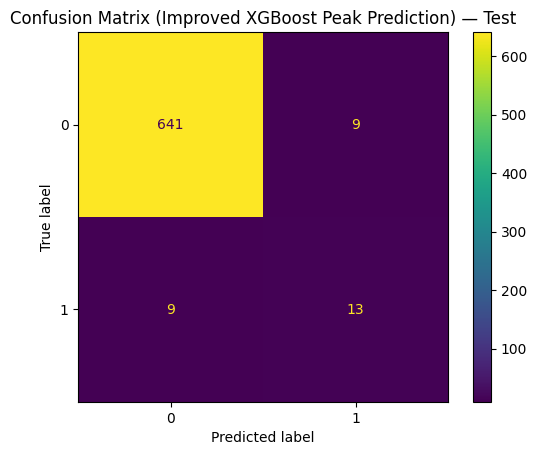

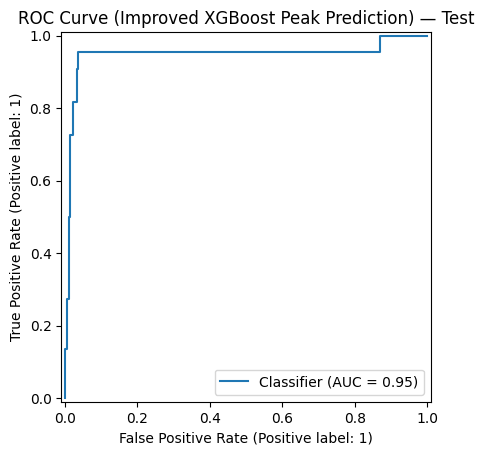

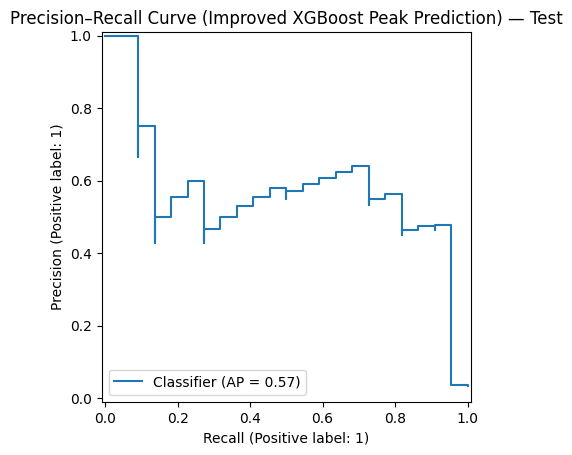

In [107]:
# Plotting evaluation curves for improved XGBoost peak model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

best_th2 = 0.2
pred_test_best2 = (xgb2_test_prob >= best_th2).astype(int)

cm2 = confusion_matrix(yc2_test, pred_test_best2)
ConfusionMatrixDisplay(confusion_matrix=cm2).plot()
plt.title("Confusion Matrix (Improved XGBoost Peak Prediction) — Test")
plt.show()

RocCurveDisplay.from_predictions(yc2_test, xgb2_test_prob)
plt.title("ROC Curve (Improved XGBoost Peak Prediction) — Test")
plt.show()

PrecisionRecallDisplay.from_predictions(yc2_test, xgb2_test_prob)
plt.title("Precision–Recall Curve (Improved XGBoost Peak Prediction) — Test")
plt.show()

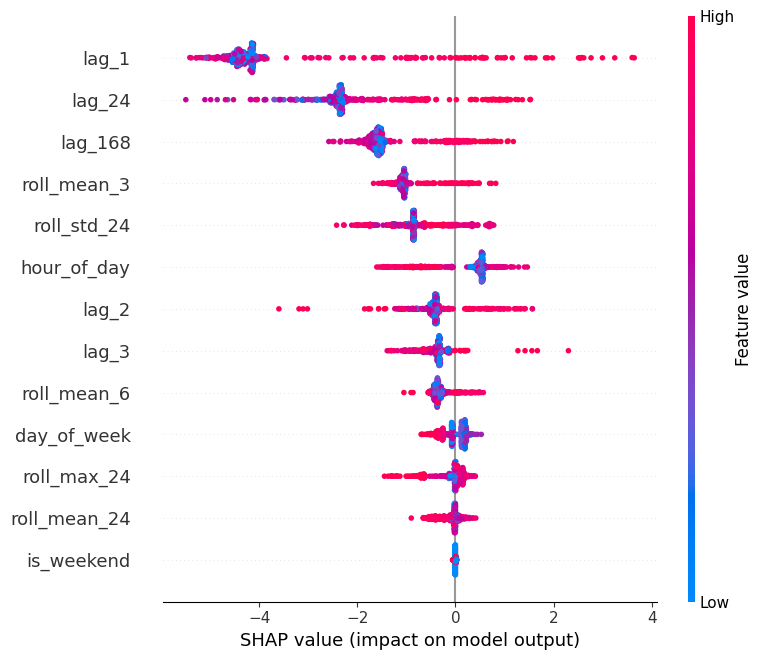

In [108]:
#  SHAP explainability for improved peak classifier

import shap
import matplotlib.pyplot as plt

explainer_c2 = shap.TreeExplainer(xgb_c2)
X2_shap = X2_test.sample(500, random_state=42)
shap_values_c2 = explainer_c2.shap_values(X2_shap)

shap.summary_plot(shap_values_c2, X2_shap, show=True)

In [109]:
# Saving improved outputs to Drive

OUT_FIG = f"{DATA_DIR}/outputs/figures"
OUT_TAB = f"{DATA_DIR}/outputs/tables"
os.makedirs(OUT_FIG, exist_ok=True)
os.makedirs(OUT_TAB, exist_ok=True)

compare_peak.to_csv(f"{OUT_TAB}/peak_model_comparison.csv", index=False)

print("Saved comparison table to:", f"{OUT_TAB}/peak_model_comparison.csv")

Saved comparison table to: /content/drive/MyDrive/NYC_TLC/outputs/tables/peak_model_comparison.csv


<Figure size 800x500 with 0 Axes>

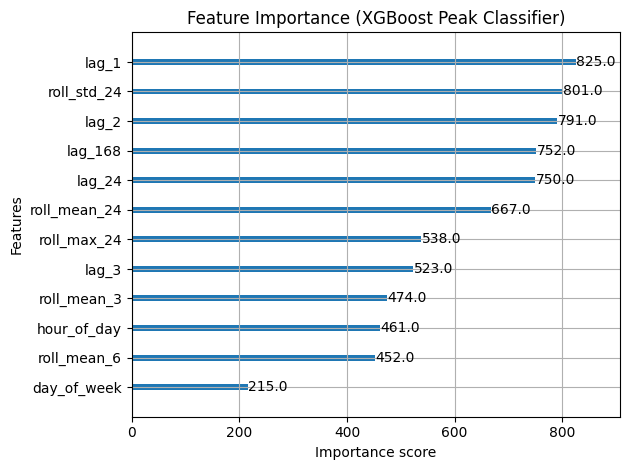

In [110]:
# XGBoost built-in feature importance (peak classifier)
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(8,5))
plot_importance(xgb_c2, max_num_features=12)
plt.title("Feature Importance (XGBoost Peak Classifier)")
plt.tight_layout()
plt.show()

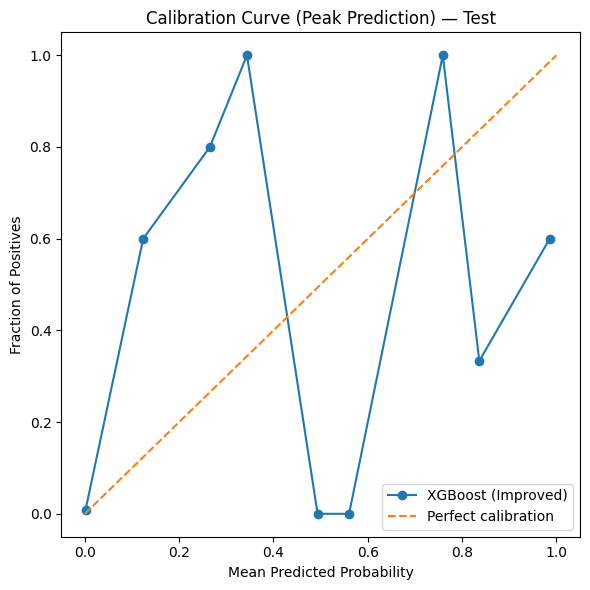

In [111]:
#  Calibration curve for improved peak classifier
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(yc2_test, xgb2_test_prob, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="XGBoost (Improved)")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.title("Calibration Curve (Peak Prediction) — Test")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend()
plt.tight_layout()
plt.show()

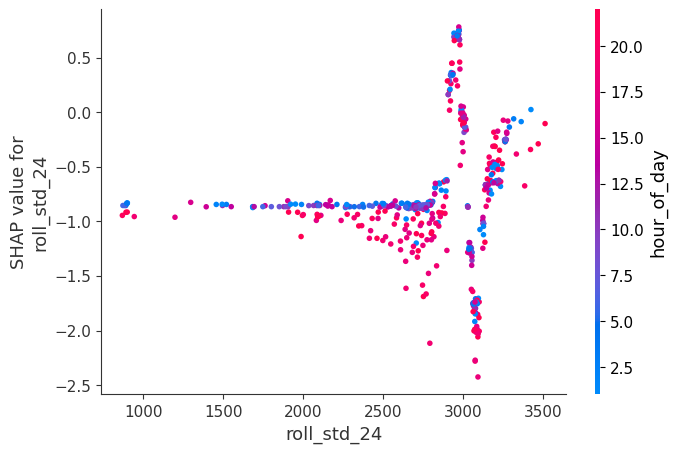

In [112]:
# SHAP dependence for roll_std_24
import shap

shap.dependence_plot("roll_std_24", shap_values_c2, X2_shap, show=True)